# Team xT Spatial Surface Visualization

This notebook visualizes **team-level expected threat (xT) creation and reception surfaces** from action-level xT values.

The goal is not to retrain the xT model. Instead, we use the action-level output from the previous notebook and ask where each team creates or receives threat on the pitch.

A key distinction:

- **Raw xT surfaces** show total threat volume. Teams with more possession, more actions, or more attacking success will naturally look larger.
- **Normalized xT surfaces** show spatial preference. Each team's surface is scaled so we can compare where threat tends to come from, independent of total volume.

In this notebook, the **sum-normalized created surface** is the main analytical result because it reduces strength/volume effects and emphasizes tactical spatial distribution.

## 1. Load Data

We load the action-level xT values created by the previous notebook. Each row should represent a successful move action such as a pass or carry, with a start zone, end zone, and xT value.

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - needed by matplotlib for 3D plotting

try:
    from scipy.ndimage import gaussian_filter
    SCIPY_AVAILABLE = True
except ImportError:
    gaussian_filter = None
    SCIPY_AVAILABLE = False

INPUT_PATH = Path("outputs/action_xt_values.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GRID_X_BINS = 16
GRID_Y_BINS = 12
N_ZONES = GRID_X_BINS * GRID_Y_BINS

required_columns = [
    "team",
    "player",
    "move_type",
    "start_zone",
    "end_zone",
    "start_x",
    "start_y",
    "end_x",
    "end_y",
    "xT_value",
]

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Expected input file not found: {INPUT_PATH}. "
        "Run the action-level xT notebook first to create outputs/action_xt_values.csv."
    )

xt_actions = pd.read_csv(INPUT_PATH)

missing_columns = sorted(set(required_columns) - set(xt_actions.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print(f"Rows loaded: {len(xt_actions):,}")
print(f"Teams loaded: {xt_actions['team'].nunique(dropna=True):,}")
print("\nxT summary:")
display(xt_actions["xT_value"].describe())

c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Rows loaded: 552,934
Teams loaded: 20

xT summary:


count    552934.000000
mean          0.000571
std           0.010202
min          -0.227657
25%          -0.000188
50%           0.000000
75%           0.000274
max           0.233048
Name: xT_value, dtype: float64

## 2. Data Cleaning

For the team-level surfaces, we keep rows with a valid team, a valid xT value, and valid 16 by 12 grid zones. We also create `positive_xT`, which clips negative values to zero.

Using positive xT focuses the visualization on where teams create threat, rather than mixing threat creation with actions that reduce expected threat.

In [2]:
rows_before_cleaning = len(xt_actions)

clean_actions = xt_actions.copy()

# Convert zones and xT to numeric values so invalid strings become NaN and can be removed safely.
clean_actions["start_zone"] = pd.to_numeric(clean_actions["start_zone"], errors="coerce")
clean_actions["end_zone"] = pd.to_numeric(clean_actions["end_zone"], errors="coerce")
clean_actions["xT_value"] = pd.to_numeric(clean_actions["xT_value"], errors="coerce")

clean_actions = clean_actions.dropna(subset=["team", "xT_value", "start_zone", "end_zone"])

valid_start_zone = clean_actions["start_zone"].between(0, N_ZONES - 1)
valid_end_zone = clean_actions["end_zone"].between(0, N_ZONES - 1)
clean_actions = clean_actions.loc[valid_start_zone & valid_end_zone].copy()

# Zone ids should be integers from 0 to 191.
clean_actions["start_zone"] = clean_actions["start_zone"].astype(int)
clean_actions["end_zone"] = clean_actions["end_zone"].astype(int)

# Main value used for threat creation surfaces.
clean_actions["positive_xT"] = clean_actions["xT_value"].clip(lower=0)

rows_after_cleaning = len(clean_actions)
rows_removed = rows_before_cleaning - rows_after_cleaning

## 3. Quality Checks

These checks confirm that the cleaned data still covers the expected teams and zone range before we aggregate into spatial surfaces.

In [3]:
quality_checks = {
    "number_of_teams": clean_actions["team"].nunique(),
    "number_of_move_actions": len(clean_actions),
    "total_positive_xT": clean_actions["positive_xT"].sum(),
    "start_zone_min": clean_actions["start_zone"].min(),
    "start_zone_max": clean_actions["start_zone"].max(),
    "end_zone_min": clean_actions["end_zone"].min(),
    "end_zone_max": clean_actions["end_zone"].max(),
    "rows_removed_during_cleaning": rows_removed,
}

for label, value in quality_checks.items():
    if isinstance(value, float):
        print(f"{label}: {value:,.6f}")
    else:
        print(f"{label}: {value:,}")

number_of_teams: 20
number_of_move_actions: 552,934
total_positive_xT: 970.124658
start_zone_min: 0
start_zone_max: 191
end_zone_min: 0
end_zone_max: 191
rows_removed_during_cleaning: 0


## 4. Team-Zone Aggregation

We build two team-by-zone matrices:

1. **Created surface**: sums `positive_xT` by `team + start_zone`.
2. **Received surface**: sums `positive_xT` by `team + end_zone`.

Every team receives all 192 zones, even if a team has zero xT in a particular zone. This keeps the grid shape stable for reshaping into 12 by 16 surfaces.

In [4]:
def build_team_zone_matrix(data, zone_column, value_column="positive_xT"):
    """Return a team-by-zone matrix with one column for every zone from 0 to 191."""
    matrix = (
        data.groupby(["team", zone_column], observed=True)[value_column]
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=range(N_ZONES), fill_value=0)
        .sort_index()
    )
    matrix.columns = [f"zone_{zone}" for zone in matrix.columns]
    return matrix

team_start_zone_xt_raw = build_team_zone_matrix(clean_actions, "start_zone")
team_end_zone_xt_raw = build_team_zone_matrix(clean_actions, "end_zone")

team_start_zone_xt_raw.to_csv(OUTPUT_DIR / "team_start_zone_xt_raw.csv")
team_end_zone_xt_raw.to_csv(OUTPUT_DIR / "team_end_zone_xt_raw.csv")

print(f"Created surface matrix shape: {team_start_zone_xt_raw.shape}")
print(f"Received surface matrix shape: {team_end_zone_xt_raw.shape}")
print("Saved raw team-zone matrices to outputs/.")

Created surface matrix shape: (20, 192)
Received surface matrix shape: (20, 192)
Saved raw team-zone matrices to outputs/.


## 5. Normalize Team Surfaces

We create two normalized versions of each surface:

- **Sum-normalized distribution**: each team's 192 zones sum to 1. This is the main analytical view because it compares spatial preference rather than total xT volume.
- **Max-normalized surface**: each team's highest zone becomes 1. This is useful for visual comparison of each team's internal hot spots.

In [5]:
def sum_normalize(matrix):
    """Scale each team row so its zone values sum to 1. Teams with no xT stay at zero."""
    row_sums = matrix.sum(axis=1)
    return matrix.div(row_sums.replace(0, np.nan), axis=0).fillna(0)


def max_normalize(matrix):
    """Scale each team row so its highest zone value is 1. Teams with no xT stay at zero."""
    row_max = matrix.max(axis=1)
    return matrix.div(row_max.replace(0, np.nan), axis=0).fillna(0)

team_start_zone_xt_distribution = sum_normalize(team_start_zone_xt_raw)
team_end_zone_xt_distribution = sum_normalize(team_end_zone_xt_raw)

team_start_zone_xt_max_normalized = max_normalize(team_start_zone_xt_raw)
team_end_zone_xt_max_normalized = max_normalize(team_end_zone_xt_raw)

team_start_zone_xt_distribution.to_csv(OUTPUT_DIR / "team_start_zone_xt_distribution.csv")
team_end_zone_xt_distribution.to_csv(OUTPUT_DIR / "team_end_zone_xt_distribution.csv")

print("Created surface distribution row-sum check:")
display(team_start_zone_xt_distribution.sum(axis=1).round(6).rename("distribution_sum").to_frame())

print("\nReceived surface distribution row-sum check:")
display(team_end_zone_xt_distribution.sum(axis=1).round(6).rename("distribution_sum").to_frame())

Created surface distribution row-sum check:


,distribution_sum
team,
Athletic Club,1.0
Atlético Madrid,1.0
Barcelona,1.0
Celta Vigo,1.0
Eibar,1.0
Espanyol,1.0
Getafe,1.0
Granada,1.0
Las Palmas,1.0



Received surface distribution row-sum check:


,distribution_sum
team,
Athletic Club,1.0
Atlético Madrid,1.0
Barcelona,1.0
Celta Vigo,1.0
Eibar,1.0
Espanyol,1.0
Getafe,1.0
Granada,1.0
Las Palmas,1.0


## 6. Team Selection

By default, we visualize the top 12 teams by total positive xT. You can also provide a manual team list. Missing manual teams are ignored gracefully so the notebook can still run.

In [6]:
# Option A: automatic top teams by total positive xT.
TOP_N_TEAMS = 12

# Option B: set this to a list such as ["Argentina", "France"] to override automatic selection.
MANUAL_TEAMS = []

team_total_positive_xt = clean_actions.groupby("team")["positive_xT"].sum().sort_values(ascending=False)

if MANUAL_TEAMS:
    available_teams = set(team_start_zone_xt_raw.index)
    selected_teams = [team for team in MANUAL_TEAMS if team in available_teams]
    missing_manual_teams = [team for team in MANUAL_TEAMS if team not in available_teams]
    if missing_manual_teams:
        print(f"Ignoring missing manual teams: {missing_manual_teams}")
else:
    selected_teams = team_total_positive_xt.head(TOP_N_TEAMS).index.tolist()

print(f"Selected teams ({len(selected_teams)}):")
for team in selected_teams:
    print(f"- {team}: total positive xT = {team_total_positive_xt.get(team, 0):.6f}")

Selected teams (12):
- Barcelona: total positive xT = 80.767541
- Real Madrid: total positive xT = 72.996868
- Sevilla: total positive xT = 57.218298
- Atlético Madrid: total positive xT = 56.046729
- Real Sociedad: total positive xT = 53.195013
- Celta Vigo: total positive xT = 48.416325
- Rayo Vallecano: total positive xT = 46.737218
- Athletic Club: total positive xT = 46.560886
- Málaga: total positive xT = 46.002651
- Valencia: total positive xT = 45.915664
- RC Deportivo La Coruña: total positive xT = 44.699170
- Eibar: total positive xT = 43.314459


## 7. 3D Surface Plotting

The plotting function below reshapes each 192-zone team vector into a **12 by 16** grid. Every subplot in a figure uses the same z-axis scale so the teams can be compared fairly within that figure.

Smoothing is optional and only changes the visual presentation, not the saved CSV matrices or summary table.

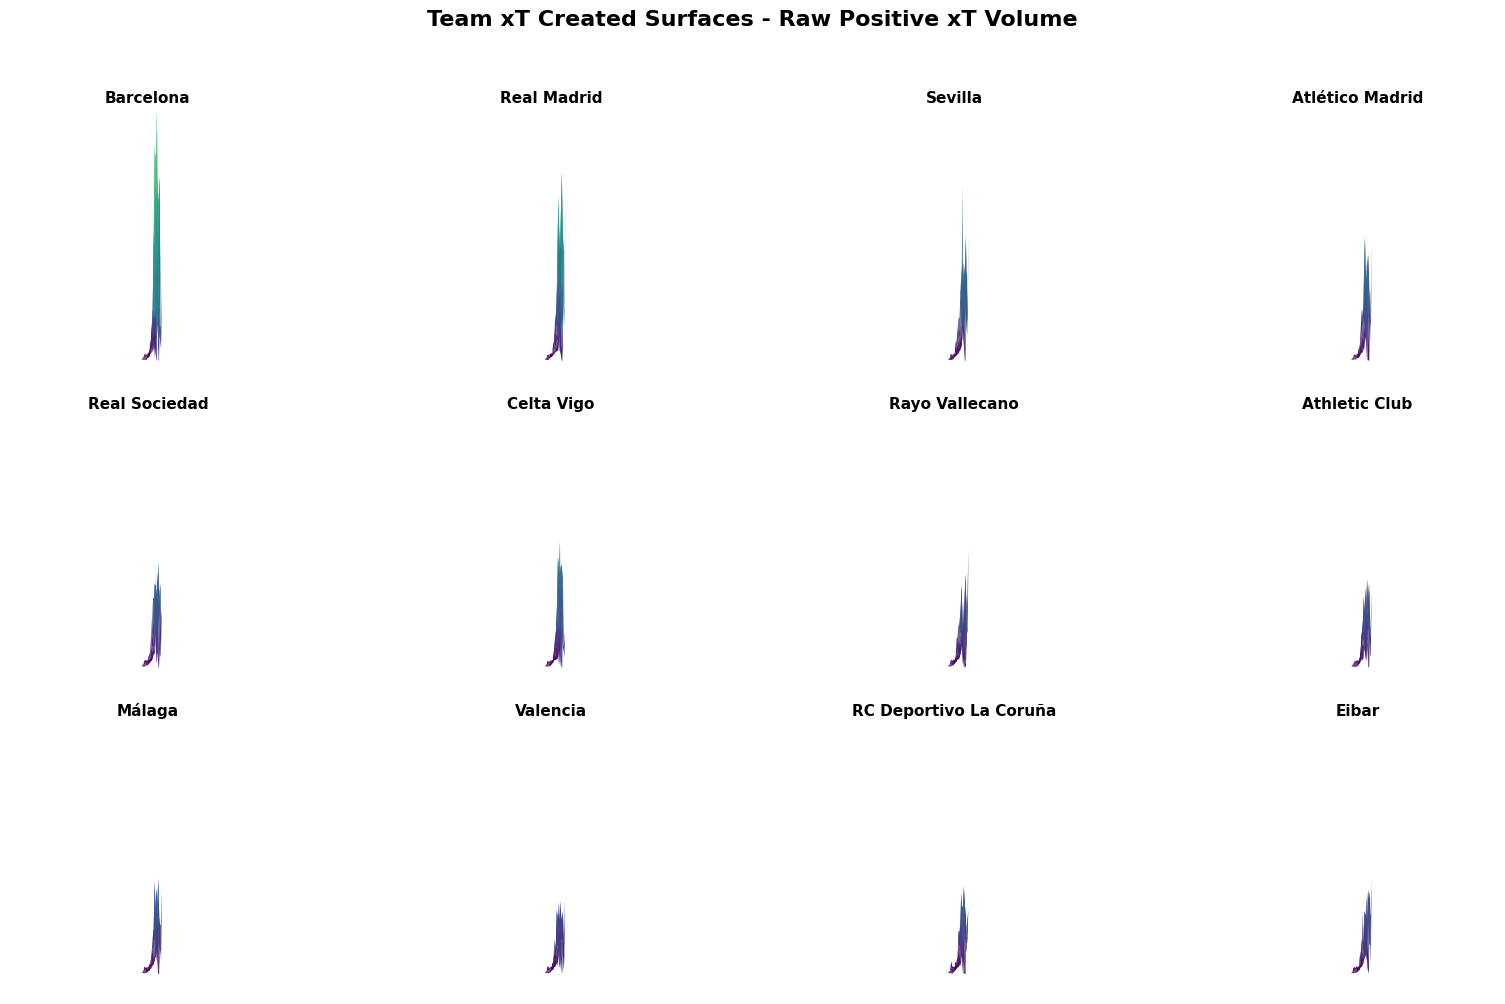

Saved figure: outputs\team_xt_created_surface_raw.png


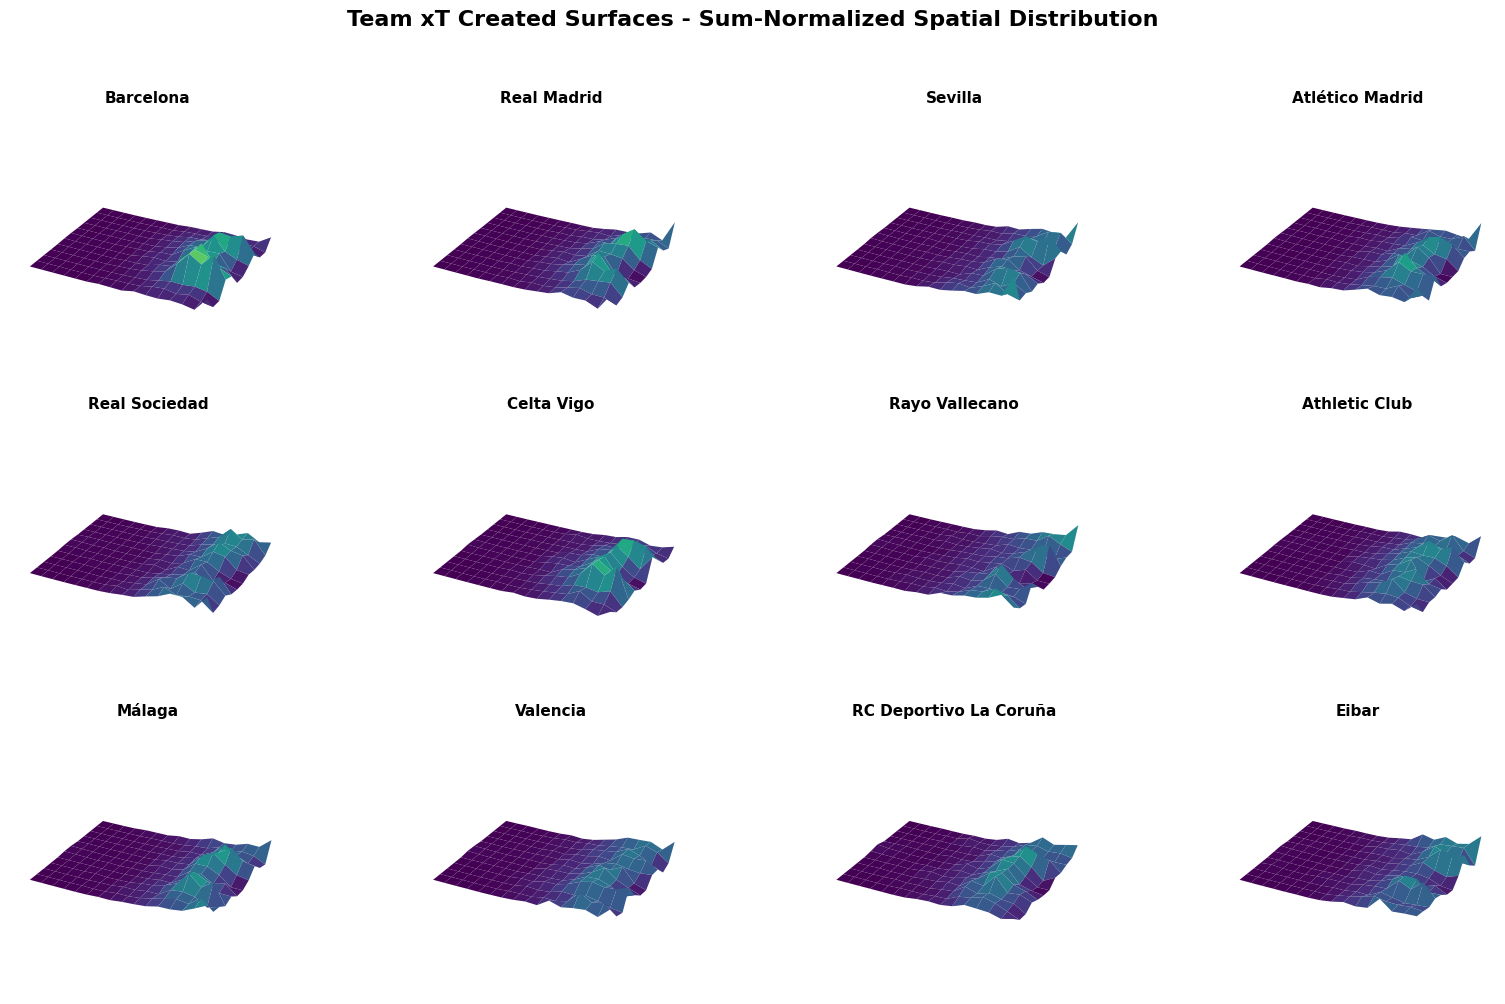

Saved figure: outputs\team_xt_created_surface_distribution.png


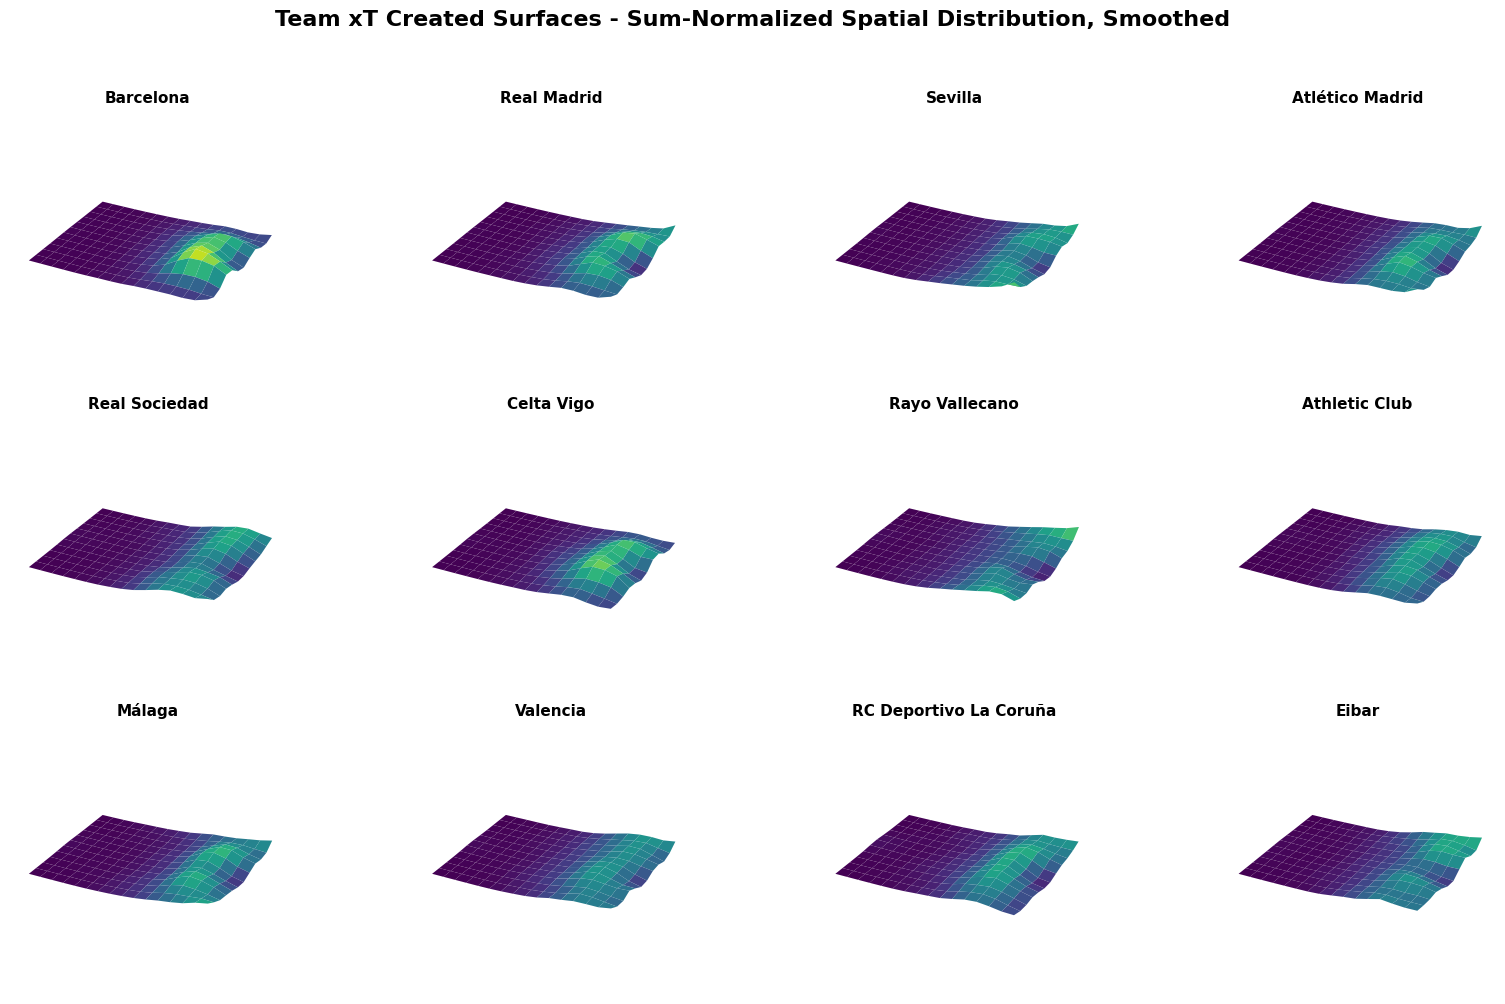

Saved figure: outputs\team_xt_created_surface_distribution_smoothed.png


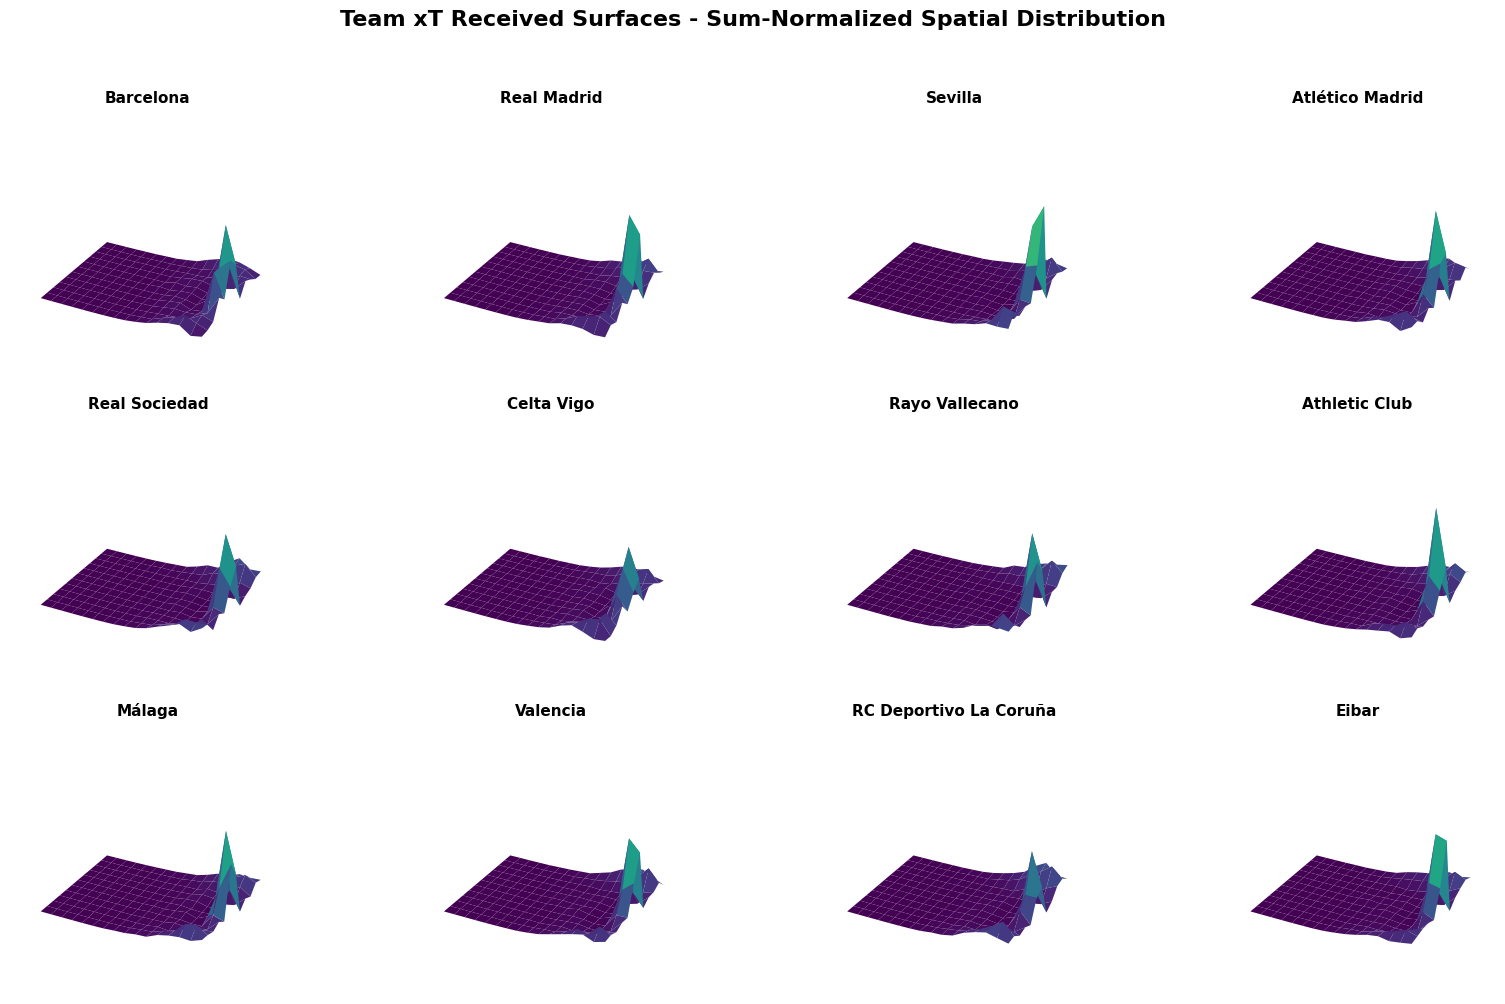

Saved figure: outputs\team_xt_received_surface_distribution.png


In [7]:
def smooth_grid(grid, sigma=0.8):
    """Apply Gaussian smoothing when SciPy is available; otherwise return the grid unchanged."""
    if sigma is None or sigma <= 0:
        return grid
    if SCIPY_AVAILABLE:
        return gaussian_filter(grid, sigma=sigma)
    print("SciPy is not installed, so smoothing was skipped.")
    return grid


def team_vector_to_grid(team_values):
    """Convert a 192-zone vector into the xT model's 12 by 16 grid."""
    return np.asarray(team_values, dtype=float).reshape(GRID_Y_BINS, GRID_X_BINS)


def plot_team_xt_surfaces(
    matrix,
    teams,
    title,
    output_path,
    n_cols=4,
    smoothing_sigma=None,
    cmap="viridis",
    view_elev=28,
    view_azim=-62,
    figsize_per_subplot=(4.2, 3.4),
):
    """Plot team-zone xT matrices as comparable 3D spatial surfaces."""
    teams = [team for team in teams if team in matrix.index]
    if not teams:
        raise ValueError("No selected teams are available in the matrix.")

    grids = {}
    for team in teams:
        grid = team_vector_to_grid(matrix.loc[team].values)
        grids[team] = smooth_grid(grid, sigma=smoothing_sigma)

    z_max = max(float(grid.max()) for grid in grids.values())
    if z_max <= 0:
        z_max = 1.0

    n_rows = math.ceil(len(teams) / n_cols)
    fig = plt.figure(figsize=(figsize_per_subplot[0] * n_cols, figsize_per_subplot[1] * n_rows))

    x = np.arange(GRID_X_BINS)
    y = np.arange(GRID_Y_BINS)
    xx, yy = np.meshgrid(x, y)

    for idx, team in enumerate(teams, start=1):
        ax = fig.add_subplot(n_rows, n_cols, idx, projection="3d")
        surface = ax.plot_surface(
            xx,
            yy,
            grids[team],
            cmap=cmap,
            linewidth=0,
            antialiased=True,
            shade=True,
            vmin=0,
            vmax=z_max,
        )
        ax.view_init(elev=view_elev, azim=view_azim)
        ax.set_zlim(0, z_max)
        ax.set_title(team, pad=0, fontsize=11, fontweight="bold")

        # Hide axes and panes so the viewer focuses on the surface shape.
        ax.set_axis_off()
        ax.set_box_aspect((GRID_X_BINS, GRID_Y_BINS, max(z_max * 70, 1)))

    for empty_idx in range(len(teams) + 1, n_rows * n_cols + 1):
        ax = fig.add_subplot(n_rows, n_cols, empty_idx, projection="3d")
        ax.set_axis_off()

    fig.suptitle(title, fontsize=16, fontweight="bold", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {output_path}")

plot_team_xt_surfaces(
    team_start_zone_xt_raw,
    selected_teams,
    title="Team xT Created Surfaces - Raw Positive xT Volume",
    output_path=OUTPUT_DIR / "team_xt_created_surface_raw.png",
    smoothing_sigma=None,
)

plot_team_xt_surfaces(
    team_start_zone_xt_distribution,
    selected_teams,
    title="Team xT Created Surfaces - Sum-Normalized Spatial Distribution",
    output_path=OUTPUT_DIR / "team_xt_created_surface_distribution.png",
    smoothing_sigma=None,
)

plot_team_xt_surfaces(
    team_start_zone_xt_distribution,
    selected_teams,
    title="Team xT Created Surfaces - Sum-Normalized Spatial Distribution, Smoothed",
    output_path=OUTPUT_DIR / "team_xt_created_surface_distribution_smoothed.png",
    smoothing_sigma=0.8,
)

plot_team_xt_surfaces(
    team_end_zone_xt_distribution,
    selected_teams,
    title="Team xT Received Surfaces - Sum-Normalized Spatial Distribution",
    output_path=OUTPUT_DIR / "team_xt_received_surface_distribution.png",
    smoothing_sigma=None,
)

## 8. Spatial Interpretation Table

The spatial summary table turns the normalized created surface into interpretable team features.

For each team, we identify its three highest-share starting zones and summarize how much of its created xT comes from the left, center, right, defensive third, middle third, and attacking third.

In [8]:
def zone_to_xy_bins(zone):
    """Convert a zone id into x-bin and y-bin positions for a 16 by 12 grid."""
    zone = int(zone)
    y_bin = zone // GRID_X_BINS
    x_bin = zone % GRID_X_BINS
    return x_bin, y_bin

zone_metadata = pd.DataFrame({"zone": range(N_ZONES)})
zone_metadata[["x_bin", "y_bin"]] = zone_metadata["zone"].apply(
    lambda zone: pd.Series(zone_to_xy_bins(zone))
)

left_zone_columns = [f"zone_{zone}" for zone in zone_metadata.loc[zone_metadata["y_bin"].between(0, 3), "zone"]]
center_zone_columns = [f"zone_{zone}" for zone in zone_metadata.loc[zone_metadata["y_bin"].between(4, 7), "zone"]]
right_zone_columns = [f"zone_{zone}" for zone in zone_metadata.loc[zone_metadata["y_bin"].between(8, 11), "zone"]]

defensive_third_columns = [f"zone_{zone}" for zone in zone_metadata.loc[zone_metadata["x_bin"].between(0, 4), "zone"]]
middle_third_columns = [f"zone_{zone}" for zone in zone_metadata.loc[zone_metadata["x_bin"].between(5, 10), "zone"]]
attacking_third_columns = [f"zone_{zone}" for zone in zone_metadata.loc[zone_metadata["x_bin"].between(11, 15), "zone"]]

summary_rows = []

for team, distribution in team_start_zone_xt_distribution.iterrows():
    top_zones = distribution.sort_values(ascending=False).head(3)
    top_zone_ids = [int(column.replace("zone_", "")) for column in top_zones.index]
    top_zone_shares = top_zones.values

    row = {
        "team": team,
        "total_positive_xT": team_total_positive_xt.get(team, 0),
        "top_zone_1": top_zone_ids[0],
        "top_zone_1_share": top_zone_shares[0],
        "top_zone_2": top_zone_ids[1],
        "top_zone_2_share": top_zone_shares[1],
        "top_zone_3": top_zone_ids[2],
        "top_zone_3_share": top_zone_shares[2],
        "left_side_share": distribution[left_zone_columns].sum(),
        "center_share": distribution[center_zone_columns].sum(),
        "right_side_share": distribution[right_zone_columns].sum(),
        "defensive_third_share": distribution[defensive_third_columns].sum(),
        "middle_third_share": distribution[middle_third_columns].sum(),
        "attacking_third_share": distribution[attacking_third_columns].sum(),
    }
    summary_rows.append(row)

team_xt_spatial_summary = pd.DataFrame(summary_rows)
team_xt_spatial_summary = team_xt_spatial_summary.sort_values(
    ["attacking_third_share", "total_positive_xT"],
    ascending=[False, False],
).reset_index(drop=True)

team_xt_spatial_summary.to_csv(OUTPUT_DIR / "team_xt_spatial_summary.csv", index=False)

print(f"Saved spatial summary: {OUTPUT_DIR / 'team_xt_spatial_summary.csv'}")
display(team_xt_spatial_summary)

Saved spatial summary: outputs\team_xt_spatial_summary.csv


,team,total_positive_xT,top_zone_1,top_zone_1_share,top_zone_2,top_zone_2_share,top_zone_3,top_zone_3_share,left_side_share,center_share,right_side_share,defensive_third_share,middle_third_share,attacking_third_share
0,Sevilla,57.218298,15,0.042299,191,0.030474,142,0.029708,0.367114,0.259461,0.373425,0.013851,0.203900,0.782249
1,Málaga,46.002651,141,0.028531,60,0.028267,124,0.025883,0.351935,0.297979,0.350085,0.018022,0.206639,0.775339
2,Real Madrid,72.996868,141,0.034710,191,0.030615,76,0.030615,0.306585,0.326548,0.366867,0.009520,0.216402,0.774078
3,Barcelona,80.767541,62,0.041144,60,0.035689,92,0.034650,0.280490,0.436287,0.283223,0.009422,0.219478,0.771100
4,Atlético Madrid,56.046729,76,0.030668,15,0.029657,191,0.029589,0.356003,0.305259,0.338739,0.010449,0.222434,0.767117
5,Real Betis,41.639681,141,0.032363,77,0.028219,190,0.025195,0.295680,0.259631,0.444689,0.018045,0.226437,0.755518
6,Celta Vigo,48.416325,62,0.036238,60,0.031875,76,0.030033,0.308719,0.399844,0.291437,0.013569,0.242413,0.744018
7,Eibar,43.314459,191,0.029774,141,0.026823,143,0.026277,0.318346,0.253403,0.428251,0.017917,0.241738,0.740344
8,Getafe,43.216544,142,0.036431,62,0.034452,189,0.029191,0.344139,0.252669,0.403192,0.020388,0.241043,0.738569
9,Real Sociedad,53.195013,172,0.026885,15,0.026073,140,0.024466,0.363447,0.255671,0.380882,0.016950,0.244807,0.738243


## 9. Interpretation Notes

- **Raw surfaces** compare total xT volume. They are useful when the question is which teams produced more positive xT overall.
- **Sum-normalized surfaces** compare spatial style. They are useful when the question is where each team tends to create threat, after reducing the effect of total volume.
- **Created surfaces** answer: ?Where does the team generate threat from?? These use `start_zone`.
- **Received surfaces** answer: ?Where does the team move threat into?? These use `end_zone`.

The normalized created surface is the best candidate for later team tactical clustering because it reduces strength and volume effects while preserving each team's spatial threat preference.